In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyBboxPatch, ConnectionPatch
import matplotlib.patheffects as path_effects

# ---------------------------------------------------------
# Global Aesthetic Settings
# ---------------------------------------------------------
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 1.2
colors = sns.color_palette("mako", 4)
accent_color = sns.color_palette("flare", 4)[1]

# ---------------------------------------------------------
# Figure 1: Bifurcation & Phase Space (Section 7.1)
# ---------------------------------------------------------
def plot_phase_space():
    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

    # FHN Parameters
    a, b, epsilon, I = 0.5, 0.5, 0.08, 0.5

    # Grid for vector field
    v = np.linspace(-2.5, 2.5, 20)
    w = np.linspace(-1.0, 2.0, 20)
    V, W = np.meshgrid(v, w)

    # Derivatives
    dV = V - (V**3)/3 - W + I
    dW = epsilon * (V + a - b * W)

    # Streamplot
    speed = np.sqrt(dV**2 + dW**2)
    strm = ax.streamplot(V, W, dV, dW, color=speed, cmap='mako', linewidth=1.5, density=1.2)
    fig.colorbar(strm.lines, ax=ax, label='Phase Velocity')

    # Nullclines
    v_line = np.linspace(-2.5, 2.5, 100)
    w_null = v_line - (v_line**3)/3 + I
    v_null = (v_line + a) / b

    ax.plot(v_line, w_null, color=accent_color, lw=3, label=r'$v$-nullcline ($\dot{v}=0$)')
    ax.plot(v_line, v_null, color='#E26D5C', lw=3, label=r'$w$-nullcline ($\dot{w}=0$)')

    # Limit Cycle Simulation (Euler method)
    t_steps = 5000
    dt = 0.05
    v_sim, w_sim = np.zeros(t_steps), np.zeros(t_steps)
    v_sim[0], w_sim[0] = 0.0, 0.0
    for i in range(1, t_steps):
        v_sim[i] = v_sim[i-1] + (v_sim[i-1] - (v_sim[i-1]**3)/3 - w_sim[i-1] + I) * dt
        w_sim[i] = w_sim[i-1] + epsilon * (v_sim[i-1] + a - b * w_sim[i-1]) * dt

    ax.plot(v_sim[2000:], w_sim[2000:], color='#2A9D8F', lw=2.5, label='Stable Limit Cycle')

    ax.set_xlim([-2.5, 2.5])
    ax.set_ylim([-1.0, 2.0])
    ax.set_xlabel('Excitation Variable ($v$)')
    ax.set_ylabel('Recovery Variable ($w$)')
    ax.set_title('FitzHugh-Nagumo Phase Space & Limit Cycle', weight='bold', pad=15)
    ax.legend(loc='lower right', frameon=True, shadow=True)
    plt.tight_layout()
    plt.savefig('Fig1_PhaseSpace.png')
    plt.close()

# ---------------------------------------------------------
# Figure 2: Sobol Sensitivity Indices (Section 7.2)
# ---------------------------------------------------------
def plot_sobol_indices():
    fig, ax = plt.subplots(figsize=(9, 5), dpi=300)

    parameters = [r'Excitation Threshold ($a$)', r'Recovery Scale ($\epsilon$)', r'Diffusion ($D$)']
    S_i = [0.15, 0.20, 0.65]        # First order
    S_T = [0.45, 0.55, 0.70]        # Total effect

    x = np.arange(len(parameters))
    width = 0.35

    rects1 = ax.bar(x - width/2, S_i, width, label='First-Order Index ($S_i$)', color=colors[1], edgecolor='black')
    rects2 = ax.bar(x + width/2, S_T, width, label='Total-Effect Index ($S_{T_i}$)', color=accent_color, edgecolor='black')

    ax.set_ylabel('Sobol Sensitivity Index')
    ax.set_title('Global Sensitivity Analysis: Spiral Wave Dynamics', weight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(parameters, weight='bold')
    ax.legend(frameon=True, shadow=True)

    # Add values on top of bars
    ax.bar_label(rects1, padding=3, fmt='%.2f')
    ax.bar_label(rects2, padding=3, fmt='%.2f')

    plt.tight_layout()
    plt.savefig('Fig2_Sobol.png')
    plt.close()

# ---------------------------------------------------------
# Figure 3: Deterministic vs Stochastic Meander (Section 7.3)
# ---------------------------------------------------------
def plot_stochastic_meander():
    fig, ax = plt.subplots(figsize=(7, 7), dpi=300)

    t = np.linspace(0, 100, 2000)
    # Parametric equations for a deterministic hypotrochoid (flower-like meander)
    R, r, d = 5, 1.5, 2
    x_det = (R - r) * np.cos(t) + d * np.cos((R - r) / r * t)
    y_det = (R - r) * np.sin(t) - d * np.sin((R - r) / r * t)

    # Add Gaussian white noise integrated over time (random walk behavior)
    np.random.seed(42)
    noise_intensity = 0.3
    x_stoch = x_det + np.cumsum(np.random.normal(0, noise_intensity, len(t)))
    y_stoch = y_det + np.cumsum(np.random.normal(0, noise_intensity, len(t)))

    ax.plot(x_stoch, y_stoch, color=accent_color, alpha=0.7, lw=1.5, label='Stochastic SPDE Drift (Fibrillation)')
    ax.plot(x_det, y_det, color=colors[3], lw=2.5, label='Deterministic Core Trajectory (VT)')

    ax.set_title('Spiral Tip Meander: Deterministic vs. SPDE', weight='bold', pad=15)
    ax.set_xlabel('Spatial Coordinate $X$ (cm)')
    ax.set_ylabel('Spatial Coordinate $Y$ (cm)')
    ax.legend(loc='upper right', frameon=True, shadow=True)
    ax.axis('equal')

    plt.tight_layout()
    plt.savefig('Fig3_Meander.png')
    plt.close()

# ---------------------------------------------------------
# Figure 4: Advanced Aesthetic Flowchart (Section 7.4)
# ---------------------------------------------------------
def draw_flowchart():
    fig, ax = plt.subplots(figsize=(10, 8), dpi=300)
    ax.axis('off')

    # Helper to create styled boxes
    def draw_box(ax, x, y, width, height, text, facecolor, edgecolor, textcolor='white'):
        box = FancyBboxPatch((x, y), width, height, boxstyle="round,pad=0.1,rounding_size=0.15",
                             fc=facecolor, ec=edgecolor, lw=2)
        ax.add_patch(box)
        txt = ax.text(x + width/2, y + height/2, text, ha='center', va='center',
                      color=textcolor, weight='bold', fontsize=11, linespacing=1.5)
        txt.set_path_effects([path_effects.withStroke(linewidth=2, foreground='black', alpha=0.3)])
        return (x + width/2, y), (x + width/2, y + height), (x, y + height/2), (x + width, y + height/2)

    # Helper to draw arrows
    def draw_arrow(ax, xyA, xyB, connectionstyle="arc3,rad=0"):
        con = ConnectionPatch(xyA=xyA, xyB=xyB, coordsA="data", coordsB="data",
                              arrowstyle="-|>,head_width=0.4,head_length=0.6", lw=2.5, color='#444444',
                              connectionstyle=connectionstyle)
        ax.add_patch(con)

    # Box coordinates & drawing
    # Row 1: Inputs
    c1, c1_top, c1_l, c1_r = draw_box(ax, 2, 7, 2.5, 1, "Extended FHN PDE\n(Fractional Order & MEF)", colors[0], '#1f2e2e')
    c2, c2_top, c2_l, c2_r = draw_box(ax, 5.5, 7, 2.5, 1, "Sparse Optical\nVoltage Data", '#E26D5C', '#8f2414')

    # Row 2: PINN Core
    c3, c3_top, c3_l, c3_r = draw_box(ax, 3.75, 5, 2.5, 1, "Physics-Informed\nNeural Network (PINN)", colors[2], '#165750')

    # Row 3: Loss Function
    c4, c4_top, c4_l, c4_r = draw_box(ax, 3.75, 3, 2.5, 1, r"Loss Function Optimization" + "\n" + r"$\mathcal{L}_{Total} = \mathcal{L}_{Data} + \lambda \mathcal{L}_{PDE}$", colors[1], '#1c364c')

    # Row 4: Outputs
    c5, c5_top, c5_l, c5_r = draw_box(ax, 1.5, 1, 2.5, 1, "Real-Time Parameter\nInference", '#D4A373', '#8b633b')
    c6, c6_top, c6_l, c6_r = draw_box(ax, 6, 1, 2.5, 1, "Generative Modeling of\nFibrillation Patterns", '#D4A373', '#8b633b')

    # Draw Connections
    draw_arrow(ax, (c1_r[0]-1.25, c1_r[1]-0.5), (c3_top[0]-0.5, c3_top[1]), connectionstyle="angle,angleA=-90,angleB=180,rad=5") # PDE to PINN
    draw_arrow(ax, (c2_l[0]+1.25, c2_l[1]-0.5), (c3_top[0]+0.5, c3_top[1]), connectionstyle="angle,angleA=-90,angleB=0,rad=5") # Data to PINN
    draw_arrow(ax, c3, c4_top) # PINN to Loss

    # Modified connection styles to avoid parallel lines
    draw_arrow(ax, (c4[0]-0.5, c4[1]), (c5_top[0], c5_top[1]), connectionstyle="angle,angleA=-90,angleB=180,rad=5") # Loss to Output 1
    draw_arrow(ax, (c4[0]+0.5, c4[1]), (c6_top[0], c6_top[1]), connectionstyle="angle,angleA=-90,angleB=0,rad=5") # Loss to Output 2

    # Loop back for optimization
    draw_arrow(ax, c4_r, (c3_r[0], c3_r[1]-0.2), connectionstyle="arc3,rad=-0.5")
    ax.text(c4_r[0]+0.3, c4_r[1]+0.8, "Backpropagation\n(Gradient Descent)", fontsize=9, style='italic', color='#555')

    ax.set_xlim(0, 10)
    ax.set_ylim(0, 9)
    ax.set_title("Architectural Flow of Data-Driven Electrophysiology", weight='bold', pad=15, fontsize=14)

    plt.tight_layout()
    plt.savefig('Fig4_Flowchart.png')
    plt.close()

# Execute all plotting functions
if __name__ == "__main__":
    plot_phase_space()
    plot_sobol_indices()
    plot_stochastic_meander()
    draw_flowchart()
    print("All figures successfully generated and saved to current directory.")

All figures successfully generated and saved to current directory.


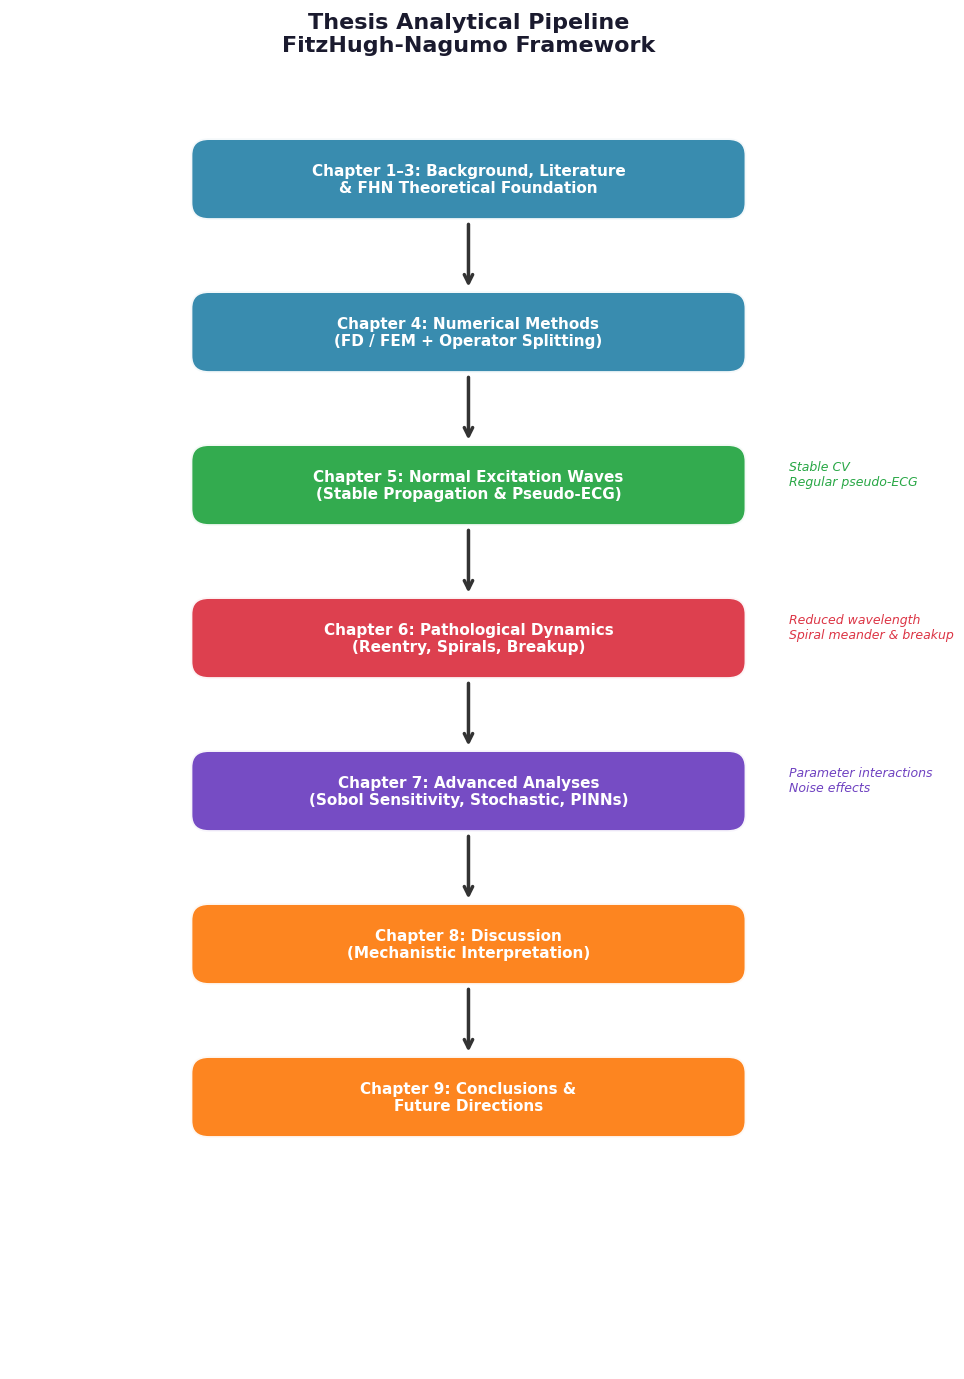

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np

fig, ax = plt.subplots(figsize=(10, 14))
ax.set_xlim(0, 10)
ax.set_ylim(0, 16)
ax.axis('off')

# Color scheme (modern professional)
colors = {
    'theory': '#2E86AB',      # Deep blue
    'normal': '#28A745',      # Green
    'pathological': '#DC3545',# Red
    'advanced': '#6F42C1',    # Purple
    'conclusion': '#FD7E14'   # Orange
}

def add_box(ax, x, y, width, height, text, color, fontsize=11):
    box = FancyBboxPatch((x - width/2, y - height/2), width, height,
                         boxstyle="round,pad=0.03,rounding_size=0.2",
                         facecolor=color, edgecolor='white', linewidth=2.5,
                         alpha=0.95)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize,
            fontweight='bold', color='white', wrap=True)

# Title
ax.text(5, 15.5, 'Thesis Analytical Pipeline\nFitzHugh-Nagumo Framework',
        ha='center', fontsize=16, fontweight='bold', color='#1a1a2e')

# Boxes
add_box(ax, 5, 14, 6, 0.9, 'Chapter 1–3: Background, Literature\n& FHN Theoretical Foundation', colors['theory'])
add_box(ax, 5, 12.2, 6, 0.9, 'Chapter 4: Numerical Methods\n(FD / FEM + Operator Splitting)', colors['theory'])
add_box(ax, 5, 10.4, 6, 0.9, 'Chapter 5: Normal Excitation Waves\n(Stable Propagation & Pseudo-ECG)', colors['normal'])
add_box(ax, 5, 8.6, 6, 0.9, 'Chapter 6: Pathological Dynamics\n(Reentry, Spirals, Breakup)', colors['pathological'])
add_box(ax, 5, 6.8, 6, 0.9, 'Chapter 7: Advanced Analyses\n(Sobol Sensitivity, Stochastic, PINNs)', colors['advanced'])
add_box(ax, 5, 5, 6, 0.9, 'Chapter 8: Discussion\n(Mechanistic Interpretation)', colors['conclusion'])
add_box(ax, 5, 3.2, 6, 0.9, 'Chapter 9: Conclusions &\nFuture Directions', colors['conclusion'])

# Arrows
arrow_style = dict(arrowstyle='->', color='#333333', lw=2.5, mutation_scale=15)
for y_start, y_end in [(13.5, 12.7), (11.7, 10.9), (9.9, 9.1), (8.1, 7.3), (6.3, 5.5), (4.5, 3.7)]:
    ax.annotate('', xy=(5, y_end), xytext=(5, y_start), arrowprops=arrow_style)

# Side annotations
ax.text(8.5, 10.4, 'Stable CV\nRegular pseudo-ECG', ha='left', fontsize=9, style='italic', color='#28A745')
ax.text(8.5, 8.6, 'Reduced wavelength\nSpiral meander & breakup', ha='left', fontsize=9, style='italic', color='#DC3545')
ax.text(8.5, 6.8, 'Parameter interactions\nNoise effects', ha='left', fontsize=9, style='italic', color='#6F42C1')

plt.tight_layout()
plt.savefig('thesis_pipeline_flowchart.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

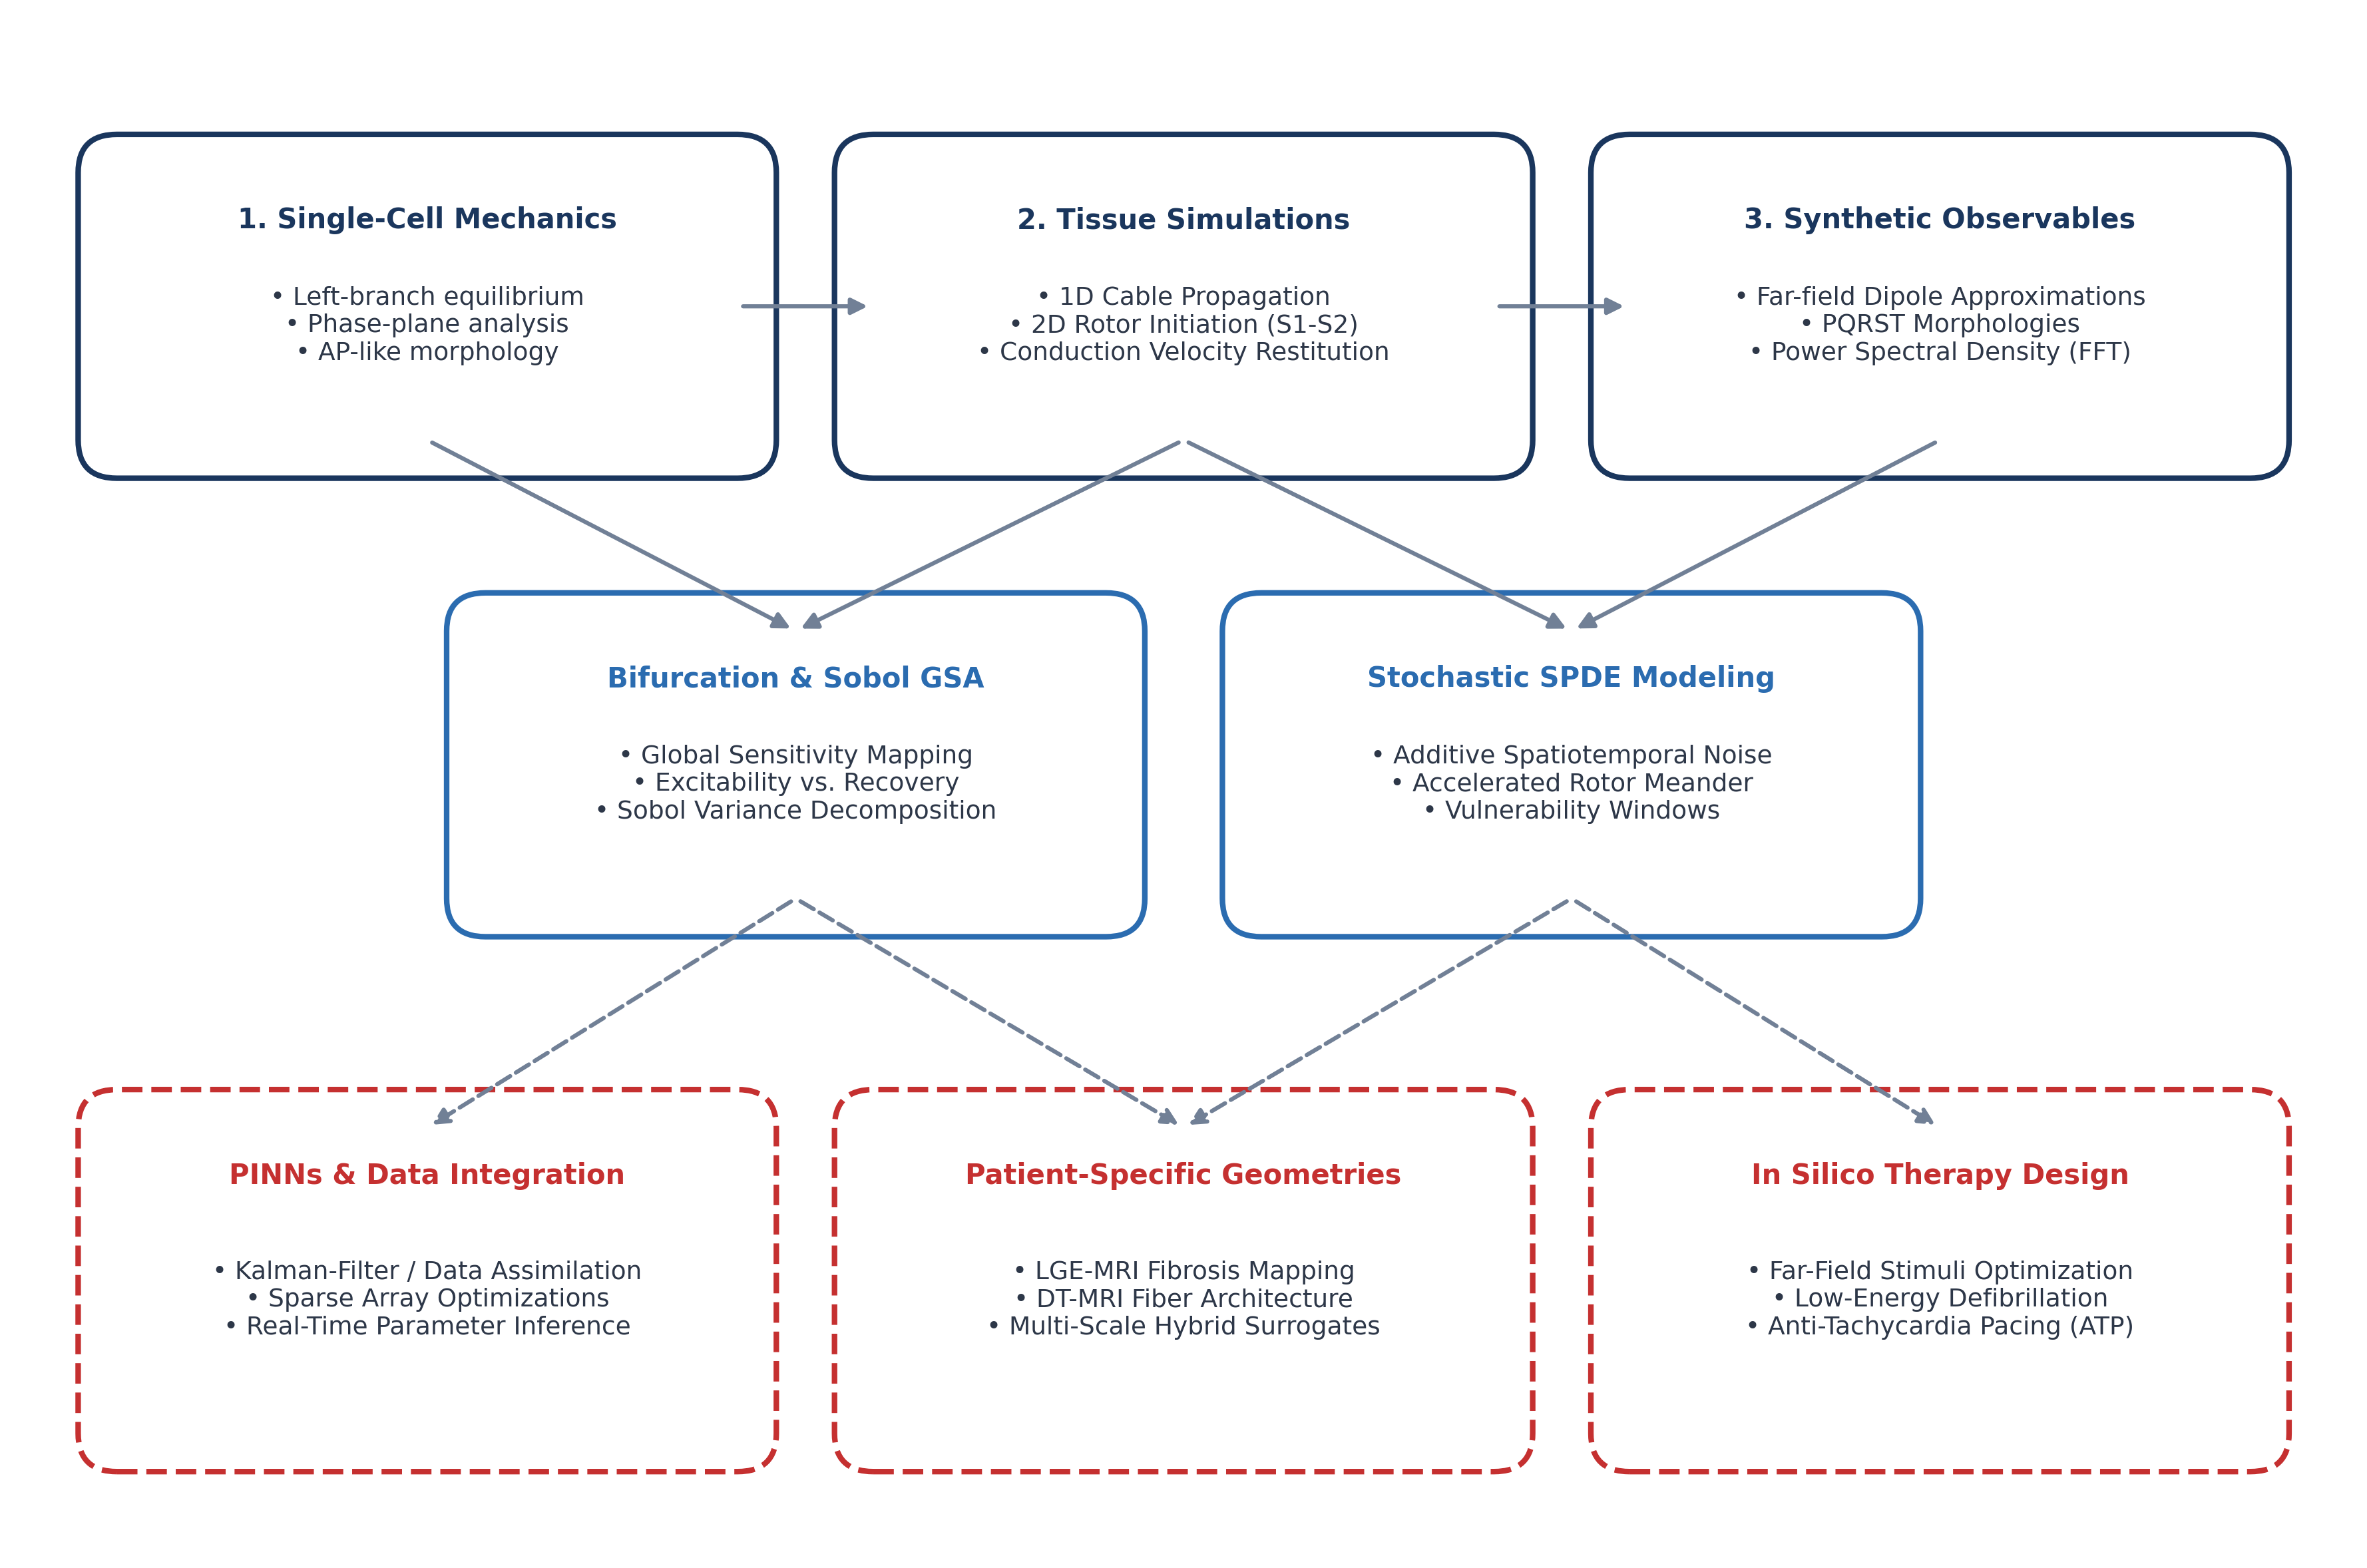

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def create_flowchart():
    # Set up figure and high-DPI canvas
    fig, ax = plt.subplots(figsize=(12, 8), dpi=300)
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 8)
    ax.axis('off')

    # Modern Minimalist Palette
    c_core = "#1A365D"      # Deep Navy: Current Work
    c_advanced = "#2B6CB0"  # Slate Blue: Advanced Analysis
    c_future = "#C53030"    # Muted Crimson: Future Directions
    c_text_dark = "#2D3748"

    # Helper function to draw stylish bounding blocks
    def draw_box(x, y, w, h, text, title, border_color, is_dashed=False):
        style = "round,pad=0.2"
        rect = patches.FancyBboxPatch(
            (x, y), w, h, boxstyle=style, edgecolor=border_color,
            facecolor="white", linewidth=2, linestyle='--' if is_dashed else '-'
        )
        ax.add_patch(rect)
        # Title text
        ax.text(x + w/2, y + h - 0.25, title, color=border_color,
                weight='bold', ha='center', va='center', fontsize=10)
        # Body text
        ax.text(x + w/2, y + h/2 - 0.1, text, color=c_text_dark,
                ha='center', va='center', fontsize=9, wrap=True)

    # Helper function to draw elegant connection vectors
    def draw_arrow(x1, y1, x2, y2, is_dashed=False):
        style = 'dashed' if is_dashed else 'solid'
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="-|>", color="#718096",
                                    linewidth=1.5, linestyle=style, mutation_scale=12))

    # --- ROW 1: CORE PHENOMENOLOGICAL FRAMEWORK ---
    draw_box(0.5, 5.8, 3.2, 1.4,
             "• Left-branch equilibrium\n• Phase-plane analysis\n• AP-like morphology",
             "1. Single-Cell Mechanics", c_core)

    draw_box(4.4, 5.8, 3.2, 1.4,
             "• 1D Cable Propagation\n• 2D Rotor Initiation (S1-S2)\n• Conduction Velocity Restitution",
             "2. Tissue Simulations", c_core)

    draw_box(8.3, 5.8, 3.2, 1.4,
             "• Far-field Dipole Approximations\n• PQRST Morphologies\n• Power Spectral Density (FFT)",
             "3. Synthetic Observables", c_core)

    draw_arrow(3.7, 6.5, 4.4, 6.5)
    draw_arrow(7.6, 6.5, 8.3, 6.5)

    # --- ROW 2: ADVANCED EXTENSIONS (CURRENT SUITE) ---
    draw_box(2.4, 3.4, 3.2, 1.4,
             "• Global Sensitivity Mapping\n• Excitability vs. Recovery\n• Sobol Variance Decomposition",
             "Bifurcation & Sobol GSA", c_advanced)

    draw_box(6.4, 3.4, 3.2, 1.4,
             "• Additive Spatiotemporal Noise\n• Accelerated Rotor Meander\n• Vulnerability Windows",
             "Stochastic SPDE Modeling", c_advanced)

    draw_arrow(2.1, 5.8, 4.0, 4.8)
    draw_arrow(6.0, 5.8, 4.0, 4.8)
    draw_arrow(6.0, 5.8, 8.0, 4.8)
    draw_arrow(9.9, 5.8, 8.0, 4.8)

    # --- ROW 3: TRANSLATION & FUTURE HORIZONS ---
    draw_box(0.5, 0.6, 3.2, 1.6,
             "• Kalman-Filter / Data Assimilation\n• Sparse Array Optimizations\n• Real-Time Parameter Inference",
             "PINNs & Data Integration", c_future, is_dashed=True)

    draw_box(4.4, 0.6, 3.2, 1.6,
             "• LGE-MRI Fibrosis Mapping\n• DT-MRI Fiber Architecture\n• Multi-Scale Hybrid Surrogates",
             "Patient-Specific Geometries", c_future, is_dashed=True)

    draw_box(8.3, 0.6, 3.2, 1.6,
             "• Far-Field Stimuli Optimization\n• Low-Energy Defibrillation\n• Anti-Tachycardia Pacing (ATP)",
             "In Silico Therapy Design", c_future, is_dashed=True)

    draw_arrow(4.0, 3.4, 2.1, 2.2, is_dashed=True)
    draw_arrow(4.0, 3.4, 6.0, 2.2, is_dashed=True)
    draw_arrow(8.0, 3.4, 6.0, 2.2, is_dashed=True)
    draw_arrow(8.0, 3.4, 9.9, 2.2, is_dashed=True)

    plt.tight_layout()
    plt.savefig("thesis_methodology_flowchart.png", dpi=300, bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    create_flowchart()

<>:31: SyntaxWarning: invalid escape sequence '\g'
<>:46: SyntaxWarning: invalid escape sequence '\e'
<>:46: SyntaxWarning: invalid escape sequence '\e'
<>:31: SyntaxWarning: invalid escape sequence '\g'
<>:46: SyntaxWarning: invalid escape sequence '\e'
<>:46: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_854/1084263039.py:31: SyntaxWarning: invalid escape sequence '\g'
  ax.axvspan(di[0], critical_di, color='#FED7D7', alpha=0.5, label='Unstable Regime (Slope $\geq$ 1)')
/tmp/ipykernel_854/1084263039.py:46: SyntaxWarning: invalid escape sequence '\e'
  parameters = ['Excitability ($a$)', 'Recovery ($\epsilon$)', 'Interaction ($a \times \epsilon$)', 'Diffusion ($D$)']
/tmp/ipykernel_854/1084263039.py:46: SyntaxWarning: invalid escape sequence '\e'
  parameters = ['Excitability ($a$)', 'Recovery ($\epsilon$)', 'Interaction ($a \times \epsilon$)', 'Diffusion ($D$)']


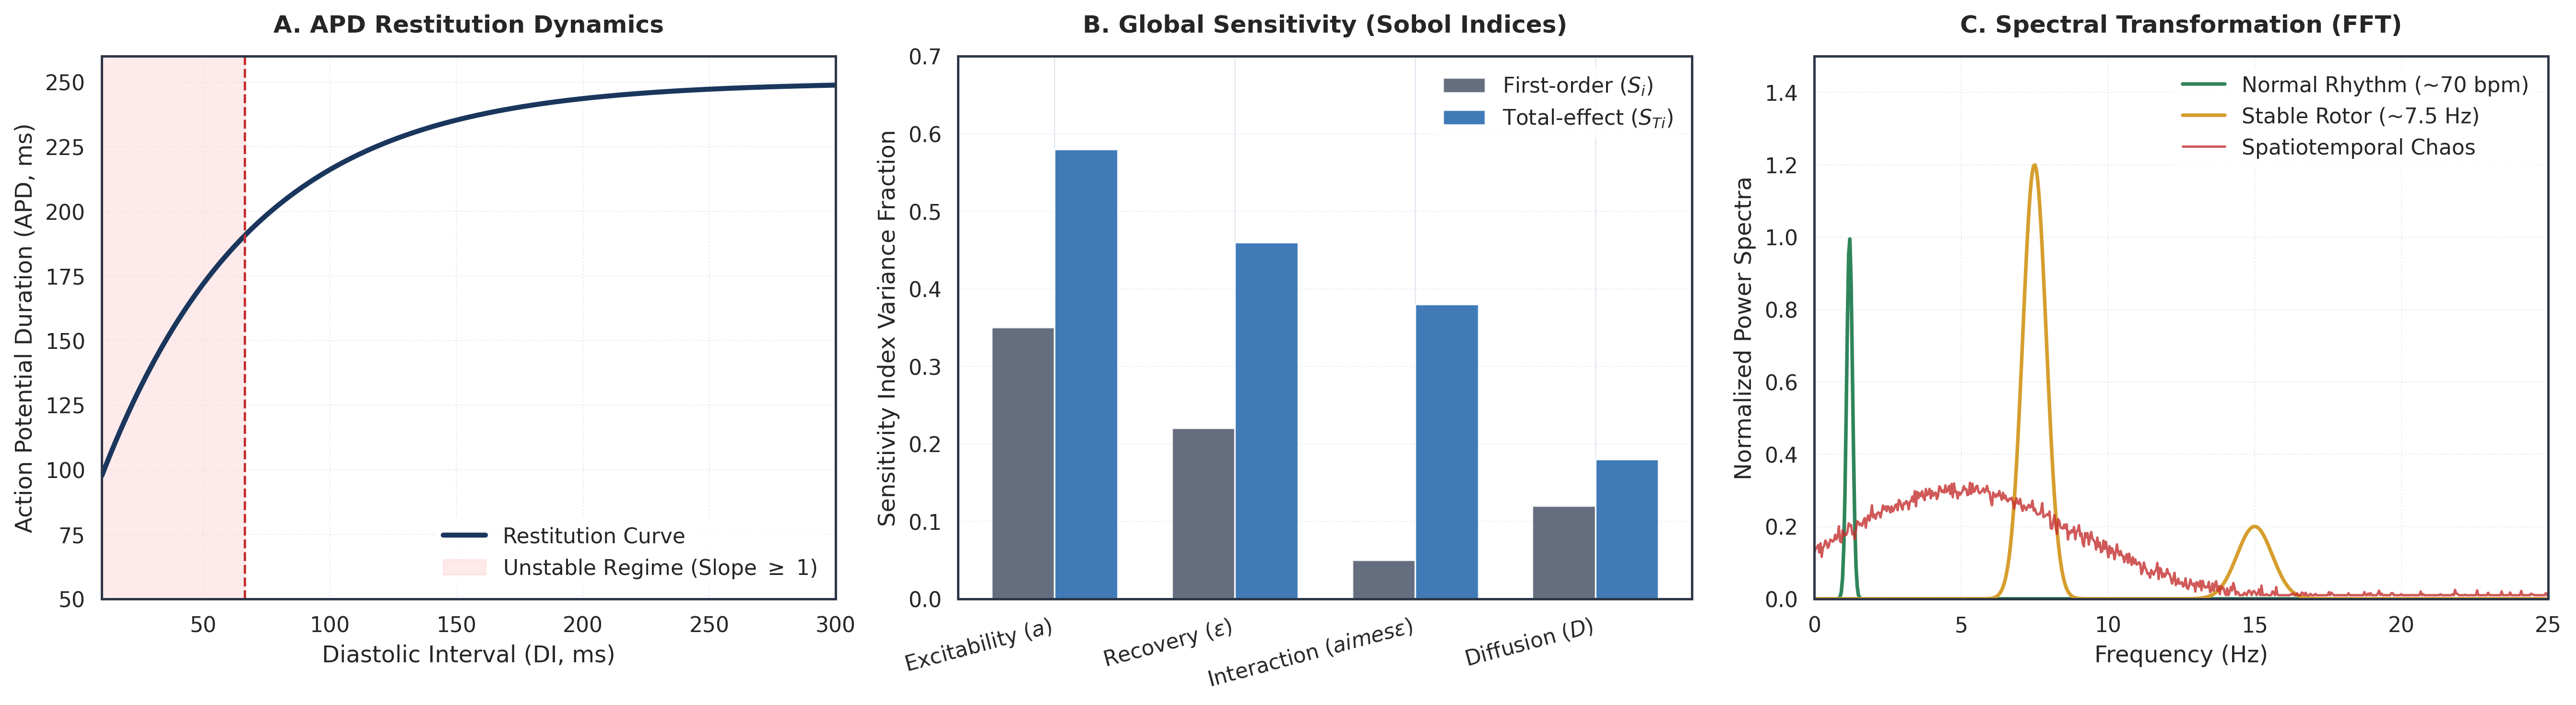

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def generate_dashboard():
    # Configure high-end academic plot styling parameters
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.size': 10,
        'axes.linewidth': 1.2,
        'axes.edgecolor': '#2D3748',
        'grid.color': '#E2E8F0',
        'grid.linewidth': 0.6
    })

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=300)

    # ----------------------------------------------------
    # PANEL A: APD Restitution Curve
    # ----------------------------------------------------
    ax = axes[0]
    di = np.linspace(10, 300, 500)
    # Phenomenological exponential restitution model
    apd = 250 - 180 * np.exp(-di / 60)

    # Calculate analytical derivative to locate critical slope boundary
    slope = (180 / 60) * np.exp(-di / 60)
    critical_idx = np.where(slope <= 1.0)[0][0]
    critical_di = di[critical_idx]

    ax.plot(di, apd, color='#1A365D', linewidth=2.5, label='Restitution Curve')
    ax.axvspan(di[0], critical_di, color='#FED7D7', alpha=0.5, label='Unstable Regime (Slope $\geq$ 1)')
    ax.axvline(critical_di, color='#C53030', linestyle='--', linewidth=1.2)

    ax.set_title("A. APD Restitution Dynamics", fontsize=12, weight='bold', pad=12)
    ax.set_xlabel("Diastolic Interval (DI, ms)")
    ax.set_ylabel("Action Potential Duration (APD, ms)")
    ax.set_xlim(10, 300)
    ax.set_ylim(50, 260)
    ax.grid(True, linestyle=':')
    ax.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='none')

    # ----------------------------------------------------
    # PANEL B: Global Sensitivity Analysis (Sobol Indices)
    # ----------------------------------------------------
    ax = axes[1]
    parameters = ['Excitability ($a$)', 'Recovery ($\epsilon$)', 'Interaction ($a \times \epsilon$)', 'Diffusion ($D$)']
    first_order = [0.35, 0.22, 0.05, 0.12]
    total_effect = [0.58, 0.46, 0.38, 0.18] # Significant interaction terms highlighted in text

    x = np.arange(len(parameters))
    width = 0.35

    ax.bar(x - width/2, first_order, width, label='First-order ($S_i$)', color='#4A5568', alpha=0.85)
    ax.bar(x + width/2, total_effect, width, label='Total-effect ($S_{Ti}$)', color='#2B6CB0', alpha=0.9)

    ax.set_title("B. Global Sensitivity (Sobol Indices)", fontsize=12, weight='bold', pad=12)
    ax.set_xticks(x)
    ax.set_xticklabels(parameters, rotation=15, ha='right')
    ax.set_ylabel("Sensitivity Index Variance Fraction")
    ax.set_ylim(0, 0.7)
    ax.grid(True, axis='y', linestyle=':')
    ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

    # ----------------------------------------------------
    # PANEL C: Power Spectral Density Transition
    # ----------------------------------------------------
    ax = axes[2]
    freq = np.linspace(0, 25, 600)

    # Phenomenological generation of spectral signatures described in Chapter 8
    normal_rhythm = 1.0 * np.exp(-((freq - 1.2)**2) / (2 * 0.1**2))
    monomorphic_rotor = 1.2 * np.exp(-((freq - 7.5)**2) / (2 * 0.4**2)) + 0.2 * np.exp(-((freq - 15.0)**2) / (2 * 0.6**2))
    fibrillation = 0.3 * np.exp(-((freq - 5.0)**2) / (2 * 4.0**2)) + 0.15 * np.random.normal(0, 0.08, len(freq))
    fibrillation = np.clip(fibrillation, 0.01, None) # Guard against unphysical negative powers

    ax.plot(freq, normal_rhythm, color='#2F855A', linewidth=1.8, label='Normal Rhythm (~70 bpm)')
    ax.plot(freq, monomorphic_rotor, color='#D69E2E', linewidth=1.8, label='Stable Rotor (~7.5 Hz)')
    ax.plot(freq, fibrillation, color='#C53030', linewidth=1.2, alpha=0.8, label='Spatiotemporal Chaos')

    ax.set_title("C. Spectral Transformation (FFT)", fontsize=12, weight='bold', pad=12)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Normalized Power Spectra")
    ax.set_xlim(0, 25)
    ax.set_ylim(0, 1.5)
    ax.grid(True, linestyle=':')
    ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

    plt.tight_layout()
    plt.savefig("thesis_quantitative_dashboard.png", dpi=300, bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    generate_dashboard()

Simulating 2D Cardiac Excitation...


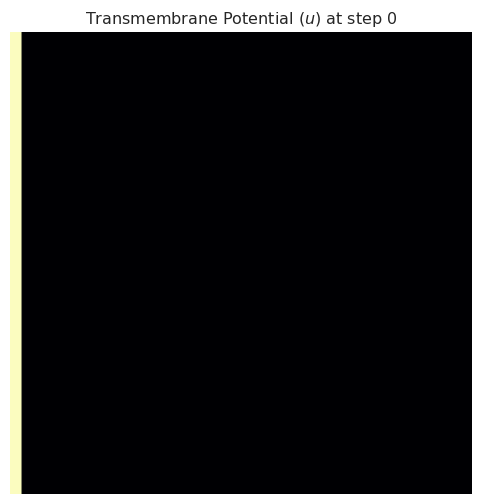

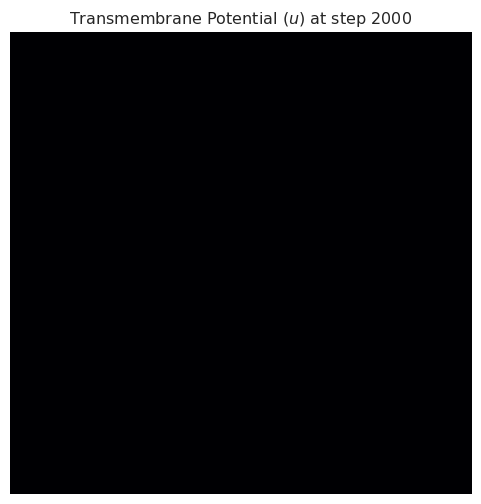

S2 Stimulus Applied - Initiating Reentry


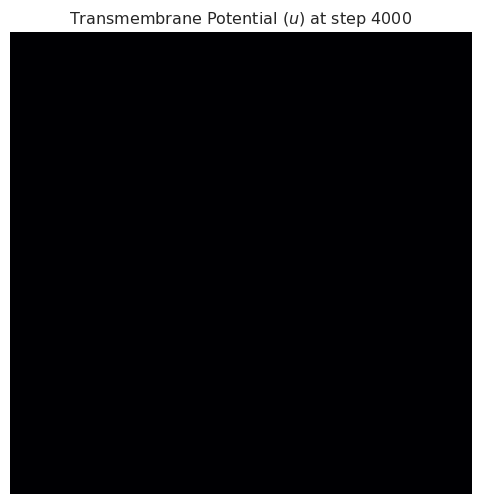

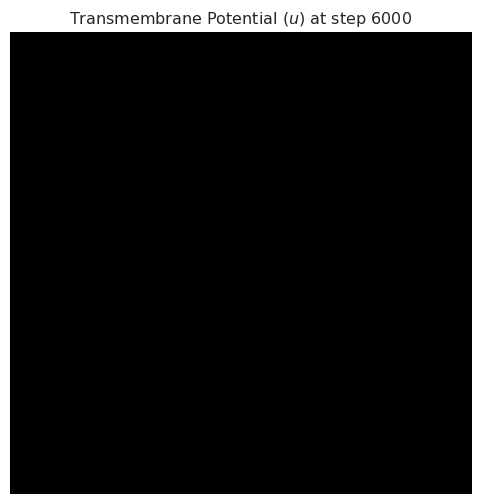

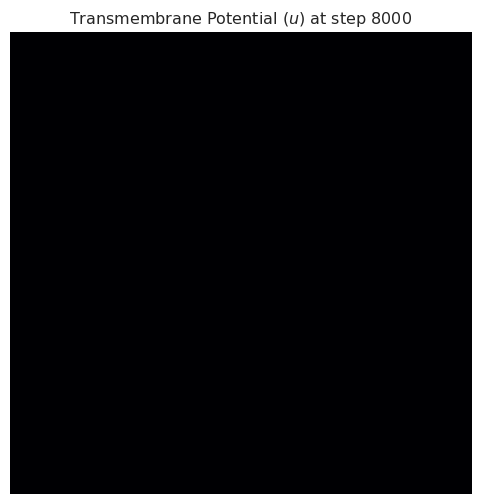

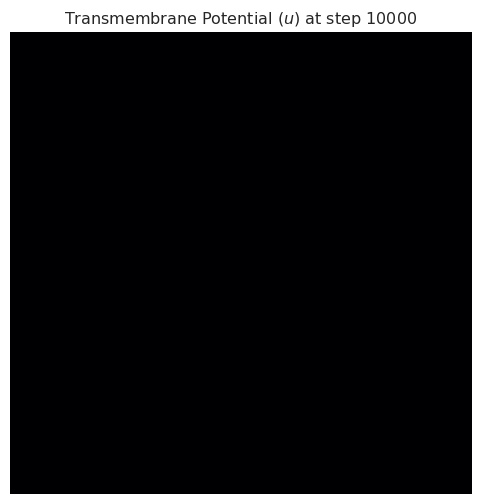

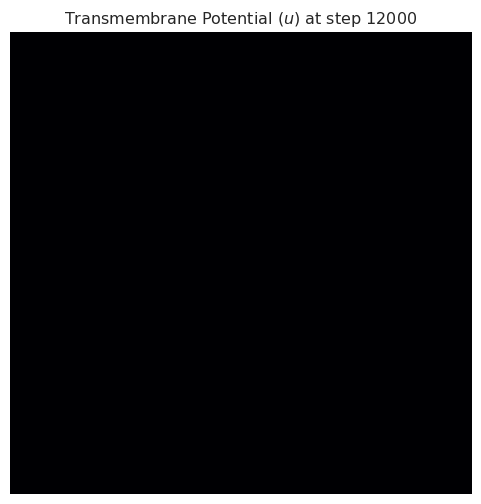

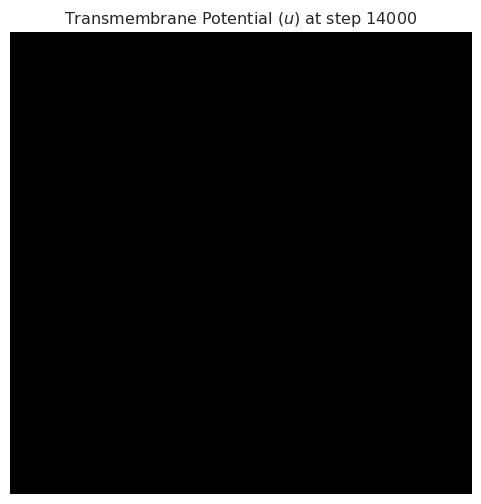

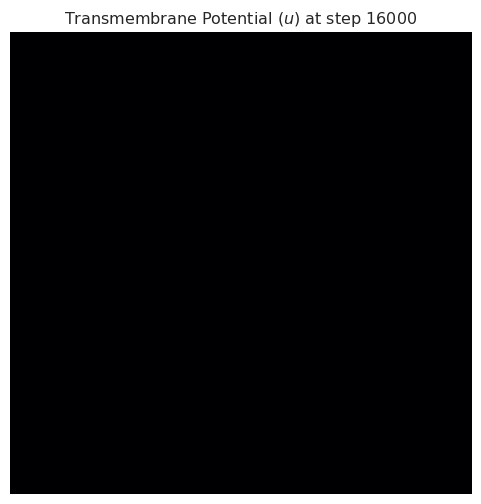

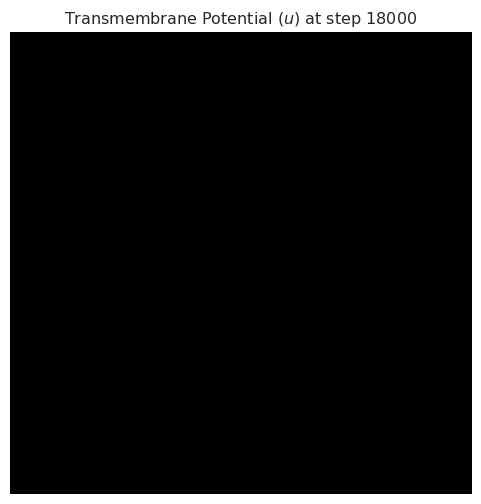

Simulation Complete.


In [ ]:
"""
Cardiac Excitation Wave Simulator: 2D Spiral Wave Generation
Model: Aliev-Panfilov Reaction-Diffusion System
Author: MD FARHAD HOSSEN
Institution: Jahangirnagar University, Department of Mathematics
Supervised by: Dr. Muhammad Humayun Kabir
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import laplace

# --- 1. Model Parameters (Aliev-Panfilov) ---
a = 0.15      # Excitation threshold
k = 8.0       # Transmembrane current scaling
eps = 0.002   # Recovery time-scale
mu1 = 0.2     # Restitution slope
mu2 = 0.3     # Restitution shift
D = 1e-3      # Diffusion coefficient

# --- 2. Grid & Time Setup ---
nx, ny = 200, 200        # Grid dimensions
dx = 1.0                 # Spatial step
dt = 0.05                # Time step
steps = 20000            # Total simulation steps

# Initialize state variables arrays
u = np.zeros((nx, ny))
v = np.zeros((nx, ny))

# --- 3. Stimulation Protocols (S1-S2) ---
def apply_S1(u):
    """Initiate a planar wavefront at the left boundary."""
    u[:, :5] = 1.0
    return u

def apply_S2(u):
    """Apply premature cross-field stimulus to induce spiral."""
    u[:nx//2, :ny//2] = 1.0
    return u

u = apply_S1(u)

# --- 4. Main Integration Loop (Euler with Finite Differences) ---
print("Simulating 2D Cardiac Excitation...")
for step in range(steps):
    # Calculate Laplacian for diffusion term (Zero-flux boundary conditions)
    lap_u = laplace(u) / (dx**2)

    # Calculate local reaction kinetics
    du_dt = D * lap_u - k * u * (u - a) * (u - 1) - u * v
    dv_dt = (eps + (mu1 * v) / (u + mu2)) * (-v - k * u * (u - a - 1))

    # Forward Euler time integration
    u += du_dt * dt
    v += dv_dt * dt

    # Apply S2 premature stimulus at specific time to hit vulnerable window
    if step == 2800:
        u = apply_S2(u)
        print("S2 Stimulus Applied - Initiating Reentry")

    # --- 5. Visualization ---
    if step % 2000 == 0:
        plt.figure(figsize=(6, 6))
        plt.imshow(u, cmap='magma', origin='lower', vmin=0, vmax=1)
        plt.title(f"Transmembrane Potential ($u$) at step {step}")
        plt.axis('off')
        plt.show()

print("Simulation Complete.")

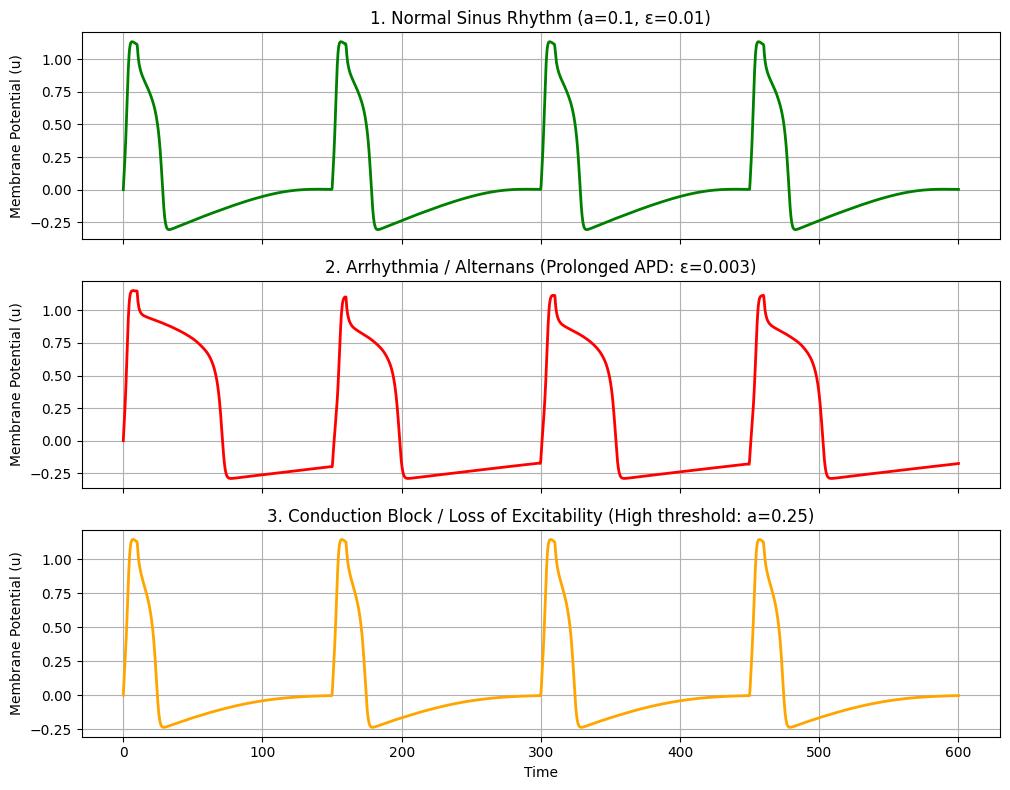

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Define the FitzHugh-Nagumo equations
def fhn_model(t, y, a, epsilon, gamma):
    u, v = y

    # S1 Pacing Stimulus: A periodic pulse to simulate the sinus node
    # Amplitude: 0.2, Duration: 10 time units, Occurs every 150 time units
    stim = 0.2 if (t % 150) < 10 else 0.0

    # Fast excitation variable (u) and slow recovery variable (v)
    du_dt = u * (1 - u) * (u - a) - v + stim
    dv_dt = epsilon * (u - gamma * v)

    return [du_dt, dv_dt]

# Simulation timeframe
t_span = (0, 600)
t_eval = np.linspace(t_span[0], t_span[1], 2000)
y0 = [0.0, 0.0] # Initial state

# --- SCENARIO 1: Regular Heart (Normal Sinus Rhythm) ---
# Parameters: Normal threshold (a=0.1), Normal recovery (epsilon=0.01)
sol_normal = solve_ivp(fhn_model, t_span, y0, args=(0.1, 0.01, 1.0), t_eval=t_eval)

# --- SCENARIO 2: Arrhythmia (Prolonged Refractoriness & Alternans) ---
# Section 6.6: Lowering epsilon prolongs the Action Potential Duration (APD)
# Simulates Long QT syndrome or Class III drugs.
sol_arr_eps = solve_ivp(fhn_model, t_span, y0, args=(0.1, 0.003, 1.0), t_eval=t_eval)

# --- SCENARIO 3: Arrhythmia (Loss of Excitability & Conduction Block) ---
# Section 6.6: Increasing 'a' mimics ischemia or sodium channel blockade.
sol_arr_a = solve_ivp(fhn_model, t_span, y0, args=(0.25, 0.01, 1.0), t_eval=t_eval)

# --- PLOTTING ---
fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# 1. Normal Plot
axs[0].plot(sol_normal.t, sol_normal.y[0], color='green', linewidth=2)
axs[0].set_title("1. Normal Sinus Rhythm (a=0.1, ε=0.01)")
axs[0].set_ylabel("Membrane Potential (u)")
axs[0].grid(True)

# 2. Arrhythmia (Low ε) Plot
axs[1].plot(sol_arr_eps.t, sol_arr_eps.y[0], color='red', linewidth=2)
axs[1].set_title("2. Arrhythmia / Alternans (Prolonged APD: ε=0.003)")
axs[1].set_ylabel("Membrane Potential (u)")
axs[1].grid(True)

# 3. Arrhythmia (High a) Plot
axs[2].plot(sol_arr_a.t, sol_arr_a.y[0], color='orange', linewidth=2)
axs[2].set_title("3. Conduction Block / Loss of Excitability (High threshold: a=0.25)")
axs[2].set_xlabel("Time")
axs[2].set_ylabel("Membrane Potential (u)")
axs[2].grid(True)

plt.tight_layout()
plt.show()